In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.dates as mdates
import os
import yfinance as yf

path = "/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance"
rfr = pd.read_csv('/common/home/lh811/Documents/ML_Pricing/data/F-F_Research_Data_Factors.csv', skiprows=3)

In [2]:
pred_storage = {}
for file in os.listdir(path):
    if file.endswith('csv'):
        model = file.split('_')[0]
        pred_storage[model] = pd.read_csv(path+'/'+file)
        

In [ ]:
def create_portfolios(dict_storage):
    '''
    Paper uses "Value Weighted portfolio", without market capitalization data, cannot replicate.

    For the sake of this project, will be a "Equal Weighted portfolio"
    '''
    all_strategy_returns = {}
    
    for key, df_raw in dict_storage.items():
        df = df_raw.copy()
        df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce', format='%Y-%m-%d')
        df['year_month'] = df['DATE'].dt.to_period('M')
        
        if 'model' in df.columns:
            methods = df['model'].unique()
            pred_col = 'pred' if 'pred' in df.columns else 'pred'
            
            for m in methods:
                filtered = df[df['model'] == m].copy()
            
                filtered['decile'] = filtered.groupby('year_month')[pred_col].transform(
                    lambda x: pd.qcut(x.rank(method='first'), 10, labels=False)
                )
                decile_returns = filtered.groupby(['year_month', 'decile'])['true'].mean().unstack()
                if 9 in decile_returns.columns and 0 in decile_returns.columns:
                    all_strategy_returns[f"{m}_Long_Short"] = decile_returns[9] - decile_returns[0]
                    
        else:
            exclude_cols = ["true", "DATE", "permno", "year_month", "Unnamed: 0"]
            methods = [c for c in df.columns if c not in exclude_cols]

            for method in methods:
                df[f'decile_{method}'] = df.groupby('year_month')[method].transform(
                    lambda x: pd.qcut(x.rank(method='first'), 10, labels=False)
                )

                decile_returns = df.groupby(['year_month', f'decile_{method}'])['true'].mean().unstack()
                if 9 in decile_returns.columns and 0 in decile_returns.columns:
                    all_strategy_returns[f"{method}_Long_Short"] = decile_returns[9] - decile_returns[0]
    
    return pd.DataFrame(all_strategy_returns)


def sharpe_ratio(df):
    monthly_mean = df.mean()
    monthly_std = df.std()
    annualized_sharpe = (monthly_mean / monthly_std) * np.sqrt(12)
    
    return pd.DataFrame({
        'Annualized_Sharpe': annualized_sharpe
    }).sort_values(by='Annualized_Sharpe', ascending=False)

In [ ]:
df = create_portfolios(pred_storage)
sr_df = sharpe_ratio(df)

In [54]:
rfr.head()
rfr = rfr.rename(columns = {'Unnamed: 0':'year_month'})
rfr['year_month'] = pd.to_datetime(rfr['year_month'], errors = 'coerce', format = '%Y%m')
rfr['year_month'] = rfr['year_month'].dt.to_period('M')
rfr['RF'] = pd.to_numeric(rfr['RF'], errors = 'coerce')/100

rfr = rfr.dropna(subset=['year_month', 'RF'])

rfr_df = rfr[['year_month', 'RF']].set_index('year_month')

print(rfr_df.head())

                RF
year_month        
1926-07     0.0022
1926-08     0.0025
1926-09     0.0023
1926-10     0.0032
1926-11     0.0031


In [36]:
spy = yf.download("SPY", start="2015-01-01", end="2021-02-01", interval="1mo")

spy_returns = spy['Close']['SPY'].pct_change().dropna()

spy_df = spy_returns.reset_index()
spy_df.columns = ['DATE', 'sp500_return']
spy_df['year_month'] = spy_df['DATE'].dt.to_period('M')

spy_df = spy_df[['year_month', 'sp500_return']].set_index('year_month')

print(spy_df.head())

[*********************100%***********************]  1 of 1 completed

            sp500_return
year_month              
2015-02         0.056205
2015-03        -0.020080
2015-04         0.014342
2015-05         0.012856
2015-06        -0.025054


In [57]:
joint = pd.merge(spy_df, rfr, how = 'inner', on = 'year_month')

joint['excess'] = joint['sp500_return'] - joint['RF']

spy_sharpe = joint['excess'].mean() - joint['excess'].std()

In [ ]:
sr_df.loc['SPY_Benchmark'] = [spy_sharpe]

sr_df = sr_df.sort_values(by='Annualized_Sharpe', ascending=False)

print(sr_df)

                  Annualized_Sharpe
enh_Long_Short             1.667167
en_Long_Short              1.616695
ols_Long_Short             1.431835
olsh_Long_Short            1.396559
nn1_Long_Short             1.355775
tree_Long_Short            1.246899
nn2_Long_Short             1.030091
treeh_Long_Short           0.918773
rf_Long_Short              0.872610
nn5_Long_Short             0.847874
nn4_Long_Short             0.694873
nn3_Long_Short             0.358121
pcr_Long_Short             0.182313
SPY_Benchmark             -0.033601


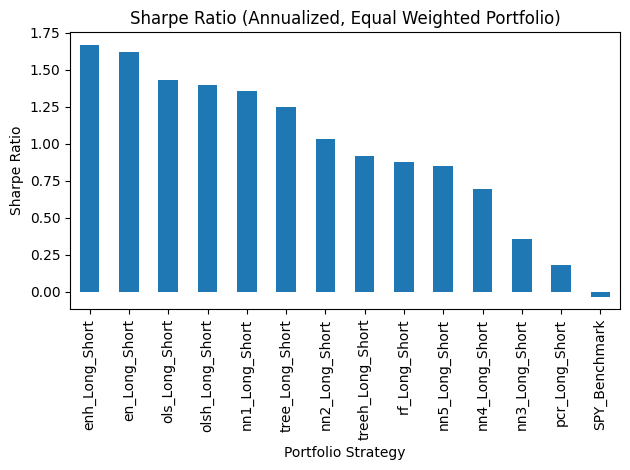

In [64]:
sr_df.plot(
    y='Annualized_Sharpe',
    kind='bar',
    legend=False
)

plt.title('Sharpe Ratio (Annualized, Equal Weighted Portfolio)')
plt.xlabel('Portfolio Strategy')
plt.ylabel('Sharpe Ratio')
plt.tight_layout()
plt.savefig('/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance/sharpe_ratio.png')
plt.show()

In [65]:
df.head()

,rf_Long_Short,ols_Long_Short,olsh_Long_Short,en_Long_Short,enh_Long_Short,pcr_Long_Short,tree_Long_Short,treeh_Long_Short,nn1_Long_Short,nn2_Long_Short,nn3_Long_Short,nn4_Long_Short,nn5_Long_Short
year_month,,,,,,,,,,,,,
2015-02,-0.030331,0.007407,0.003965,0.013808,0.012453,-0.037989,-0.026106,-0.037185,0.007954,0.000623,0.022020,-0.037959,0.017583
2015-03,0.036058,0.036721,0.039802,0.051596,0.052769,0.030726,0.052628,0.059583,0.049196,0.046850,0.013310,0.055779,0.027157
2015-04,-0.010853,-0.016818,-0.015493,-0.036639,-0.035244,-0.035918,-0.037950,-0.044463,-0.025932,-0.022608,-0.038671,-0.059354,-0.040318
2015-05,-0.000836,0.052048,0.052021,0.053564,0.053100,0.002409,0.053004,0.046312,0.058919,0.051726,0.005529,0.037777,0.047678
2015-06,0.028930,0.013377,0.015191,0.027178,0.028110,0.006585,0.012721,0.017552,0.008981,0.013282,0.009172,0.019276,0.001448


FileNotFoundError: [Errno 2] No such file or directory: '/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_perfromance/cumulative_returns.png'

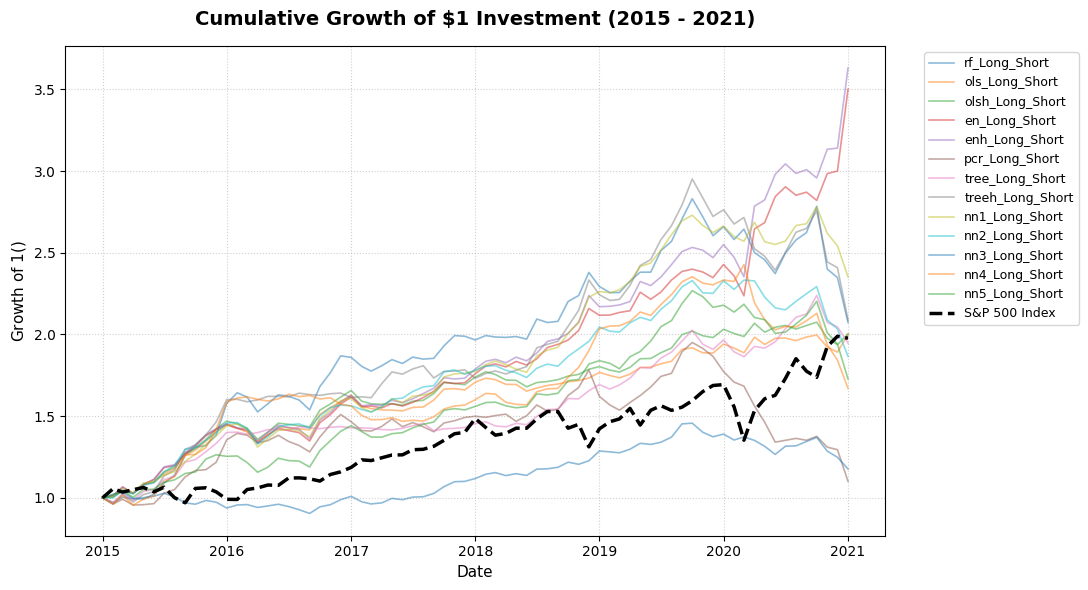

In [67]:
spy_series = joint.set_index('year_month')['excess']

# Create a combined copy for plotting
plot_df = df.copy()
plot_df['S&P 500'] = spy_series

# 2. Convert to Cumulative Returns (1 + r).cumprod()
# We fillna(0) and add a starting row of 1.0 to ensure all lines start at the exact same point
cum_returns = (1 + plot_df).cumprod()

# Add a baseline row at the very beginning so the chart starts cleanly at 1.0
start_idx = cum_returns.index[0] - 1
cum_returns.loc[start_idx] = 1.0
cum_returns = cum_returns.sort_index()

# 3. Plotting
plt.figure(figsize=(11, 6))

# Plot your machine learning models (thin lines)
for col in cum_returns.columns:
    if col != 'S&P 500':
        plt.plot(cum_returns.index.to_timestamp(), cum_returns[col], alpha=0.5, linewidth=1.2, label=col)

# Plot the S&P 500 benchmark (Thick, distinct black dashed line so it stands out)
plt.plot(cum_returns.index.to_timestamp(), cum_returns['S&P 500'], color='black', linewidth=2.5, linestyle='--', label='S&P 500 Index')

# 4. Styling and Formatting
plt.title('Cumulative Growth of $1 Investment (2015 - 2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Growth of $1 ($)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_perfromance/cumulative_returns.png', dpi=300)
plt.show()